# 00. Materialización de las condiciones de entrada del experimento

Este notebook genera y valida las representaciones de entrada que se comparan en el experimento de clasificación bajo un protocolo común:

- **A. Imagen completa:** ecografía original, sin recorte.
- **B. ROI predicha:** región de interés obtenida a partir de la máscara predicha por el U-Net baseline congelado.
- **C. ROI de referencia:** región de interés obtenida a partir de la máscara de referencia del conjunto de datos, utilizada como condición idealizada.

La segmentación interviene únicamente como mecanismo para obtener la región de interés de las condiciones B y C; no constituye una etapa obligatoria previa a la clasificación.

> En esta fase no se entrena ninguna CNN y no se utiliza el conjunto `test` para tomar decisiones sobre el procedimiento de ROI. La inspección se realiza exclusivamente con `validation`.

## 1. Configuración del entorno

El U-Net se mantiene **congelado**. Se reutilizan el checkpoint y el umbral definidos en R4.

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display


def locate_project_root() -> Path:
    current_dir = Path.cwd().resolve()

    for candidate in [current_dir, *current_dir.parents]:
        if (
            (candidate / "src").exists()
            and (
                candidate
                / "data"
                / "processed"
                / "MMOTU_OTU_2D_experimental"
            ).exists()
        ):
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto."
    )


PROJECT_ROOT = locate_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "MMOTU_OTU_2D_experimental"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "segmentation"
    / "unet_baseline_best.pth"
)

VAL_METRICS_PATH = (
    PROJECT_ROOT
    / "results"
    / "segmentation"
    / "unet_baseline"
    / "validation"
    / "validation_per_image_metrics.csv"
)

THRESHOLD_DEFAULT = 0.5
MARGIN_RATIO = 0.10

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Project root:", PROJECT_ROOT)
print("Checkpoint:", MODEL_PATH)
print("Validation metrics:", VAL_METRICS_PATH)
print("Device:", device)
print("Margen inicial:", MARGIN_RATIO)

Project root: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification
Checkpoint: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/models/segmentation/unet_baseline_best.pth
Validation metrics: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline/validation/validation_per_image_metrics.csv
Device: cuda
Margen inicial: 0.1


## 2. Carga del U-Net baseline congelado

Se recupera el mejor checkpoint seleccionado previamente mediante Dice de validación. El modelo se utiliza únicamente en modo de inferencia.

In [3]:
from src.segmentation.unet import UNet
from src.segmentation.roi import (
    extract_roi_from_mask,
    predict_and_extract_roi,
)


checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
)

IMAGE_SIZE = tuple(
    checkpoint.get("image_size", (256, 256))
)

THRESHOLD = float(
    checkpoint.get("threshold", THRESHOLD_DEFAULT)
)

model = UNet(
    in_channels=3,
    out_channels=1,
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False


print("Época del checkpoint:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Image size:", IMAGE_SIZE)
print("Threshold:", THRESHOLD)
print("U-Net congelado:", not any(
    parameter.requires_grad
    for parameter in model.parameters()
))

/tmp/ipykernel_279955/2884025643.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Época del checkpoint: 45
Validation Dice: 0.714591618180275
Image size: (256, 256)
Threshold: 0.5
U-Net congelado: True


## 3. Selección de casos de validación

Para comprobar el comportamiento de la ROI bajo distintos niveles de calidad de segmentación se seleccionan:

- el caso con menor Dice;
- un caso cercano a la mediana;
- el caso con mayor Dice.

Esta selección se realiza únicamente sobre `validation`.

In [4]:
val_metrics_df = pd.read_csv(
    VAL_METRICS_PATH,
    dtype={"image_id": str},
)

val_metrics_df = (
    val_metrics_df
    .sort_values("dice")
    .reset_index(drop=True)
)

worst_case = val_metrics_df.iloc[0]

median_position = len(val_metrics_df) // 2
median_case = val_metrics_df.iloc[median_position]

best_case = val_metrics_df.iloc[-1]


selected_cases = pd.DataFrame(
    [
        {
            "caso": "Peor",
            "image_id": worst_case["image_id"],
            "dice": worst_case["dice"],
            "iou": worst_case["iou"],
        },
        {
            "caso": "Mediano",
            "image_id": median_case["image_id"],
            "dice": median_case["dice"],
            "iou": median_case["iou"],
        },
        {
            "caso": "Mejor",
            "image_id": best_case["image_id"],
            "dice": best_case["dice"],
            "iou": best_case["iou"],
        },
    ]
)

display(selected_cases)

,caso,image_id,dice,iou
0,Peor,775,5.380104e-12,5.380104e-12
1,Mediano,349,8.222507e-01,6.981542e-01
2,Mejor,239,9.845318e-01,9.695348e-01


## 4. Funciones auxiliares para localizar imagen y máscara

Las imágenes y máscaras se cargan en su resolución original. La máscara predicha por U-Net se transforma posteriormente a esa misma resolución antes de calcular el bounding box.

In [5]:
VALIDATION_IMAGES_DIR = (
    DATASET_DIR
    / "validation"
    / "images"
)

VALIDATION_MASKS_DIR = (
    DATASET_DIR
    / "validation"
    / "masks"
)


def find_file_by_stem(directory: Path, stem: str) -> Path:
    matches = [
        path
        for path in directory.iterdir()
        if (
            path.is_file()
            and path.stem.lower() == stem.lower()
        )
    ]

    if len(matches) != 1:
        raise FileNotFoundError(
            f"Se esperaba un archivo para stem={stem}, "
            f"pero se encontraron {len(matches)}."
        )

    return matches[0]


def load_case(image_id: str):
    image_id = str(image_id)

    image_path = find_file_by_stem(
        VALIDATION_IMAGES_DIR,
        image_id,
    )

    mask_path = find_file_by_stem(
        VALIDATION_MASKS_DIR,
        f"{image_id}_binary",
    )

    with Image.open(image_path) as image:
        image = image.convert("RGB").copy()

    with Image.open(mask_path) as mask:
        gt_mask = np.asarray(
            mask.convert("L"),
            dtype=np.uint8,
        )

    gt_mask = (gt_mask > 0).astype(np.uint8)

    return image, gt_mask, image_path, mask_path

## 5. Generación de ROI predicha y ROI de referencia

El procedimiento es exactamente el mismo para las dos máscaras:

1. conservar la componente conexa principal;
2. calcular el bounding box;
3. aplicar un margen proporcional;
4. recortar sobre la **imagen original**.

La única diferencia es el origen de la máscara: predicción U-Net o ground truth.

Si la máscara predicha está vacía, se utiliza la imagen completa como fallback.

In [6]:
def draw_bbox(image: Image.Image, bbox):
    output = image.copy()

    draw = ImageDraw.Draw(output)

    left, top, right, bottom = bbox

    draw.rectangle(
        [left, top, right - 1, bottom - 1],
        outline="white",
        width=max(2, image.width // 250),
    )

    return output


case_results = {}

for row in selected_cases.itertuples():
    image_id = str(row.image_id)

    image, gt_mask, image_path, mask_path = load_case(
        image_id
    )

    predicted_result, probability_map = (
        predict_and_extract_roi(
            model=model,
            image=image,
            device=device,
            image_size=IMAGE_SIZE,
            threshold=THRESHOLD,
            margin_ratio=MARGIN_RATIO,
            keep_largest=True,
            fallback_to_full_image=True,
        )
    )

    gt_result = extract_roi_from_mask(
        image=image,
        binary_mask=gt_mask,
        margin_ratio=MARGIN_RATIO,
        keep_largest=True,
        fallback_to_full_image=True,
    )

    case_results[row.caso] = {
        "image_id": image_id,
        "dice": float(row.dice),
        "iou": float(row.iou),
        "image": image,
        "gt_mask": gt_mask,
        "probability_map": probability_map,
        "predicted_result": predicted_result,
        "gt_result": gt_result,
        "image_path": image_path,
        "mask_path": mask_path,
    }


summary = []

for case_name, result in case_results.items():
    pred = result["predicted_result"]
    gt = result["gt_result"]

    summary.append(
        {
            "caso": case_name,
            "image_id": result["image_id"],
            "dice_segmentacion": result["dice"],
            "pred_bbox": pred.bbox,
            "gt_bbox": gt.bbox,
            "pred_fallback": pred.used_fallback,
            "gt_fallback": gt.used_fallback,
            "pred_roi_size": pred.roi.size,
            "gt_roi_size": gt.roi.size,
        }
    )

roi_summary_df = pd.DataFrame(summary)

display(roi_summary_df)

,caso,image_id,dice_segmentacion,pred_bbox,gt_bbox,pred_fallback,gt_fallback,pred_roi_size,gt_roi_size
0,Peor,775,5.380104e-12,"(412, 140, 425, 144)","(84, 80, 443, 376)",False,False,"(13, 4)","(359, 296)"
1,Mediano,349,8.222507e-01,"(147, 183, 304, 347)","(141, 170, 309, 326)",False,False,"(157, 164)","(168, 156)"
2,Mejor,239,9.845318e-01,"(0, 42, 467, 439)","(0, 38, 460, 441)",False,False,"(467, 397)","(460, 403)"


## 6. Inspección visual

Para cada caso se muestran:

1. imagen original;
2. máscara de referencia;
3. máscara predicha;
4. bounding box predicho sobre la imagen original;
5. ROI predicha;
6. ROI de referencia.

La inspección permite comprobar especialmente qué ocurre cuando el U-Net produce una segmentación deficiente.

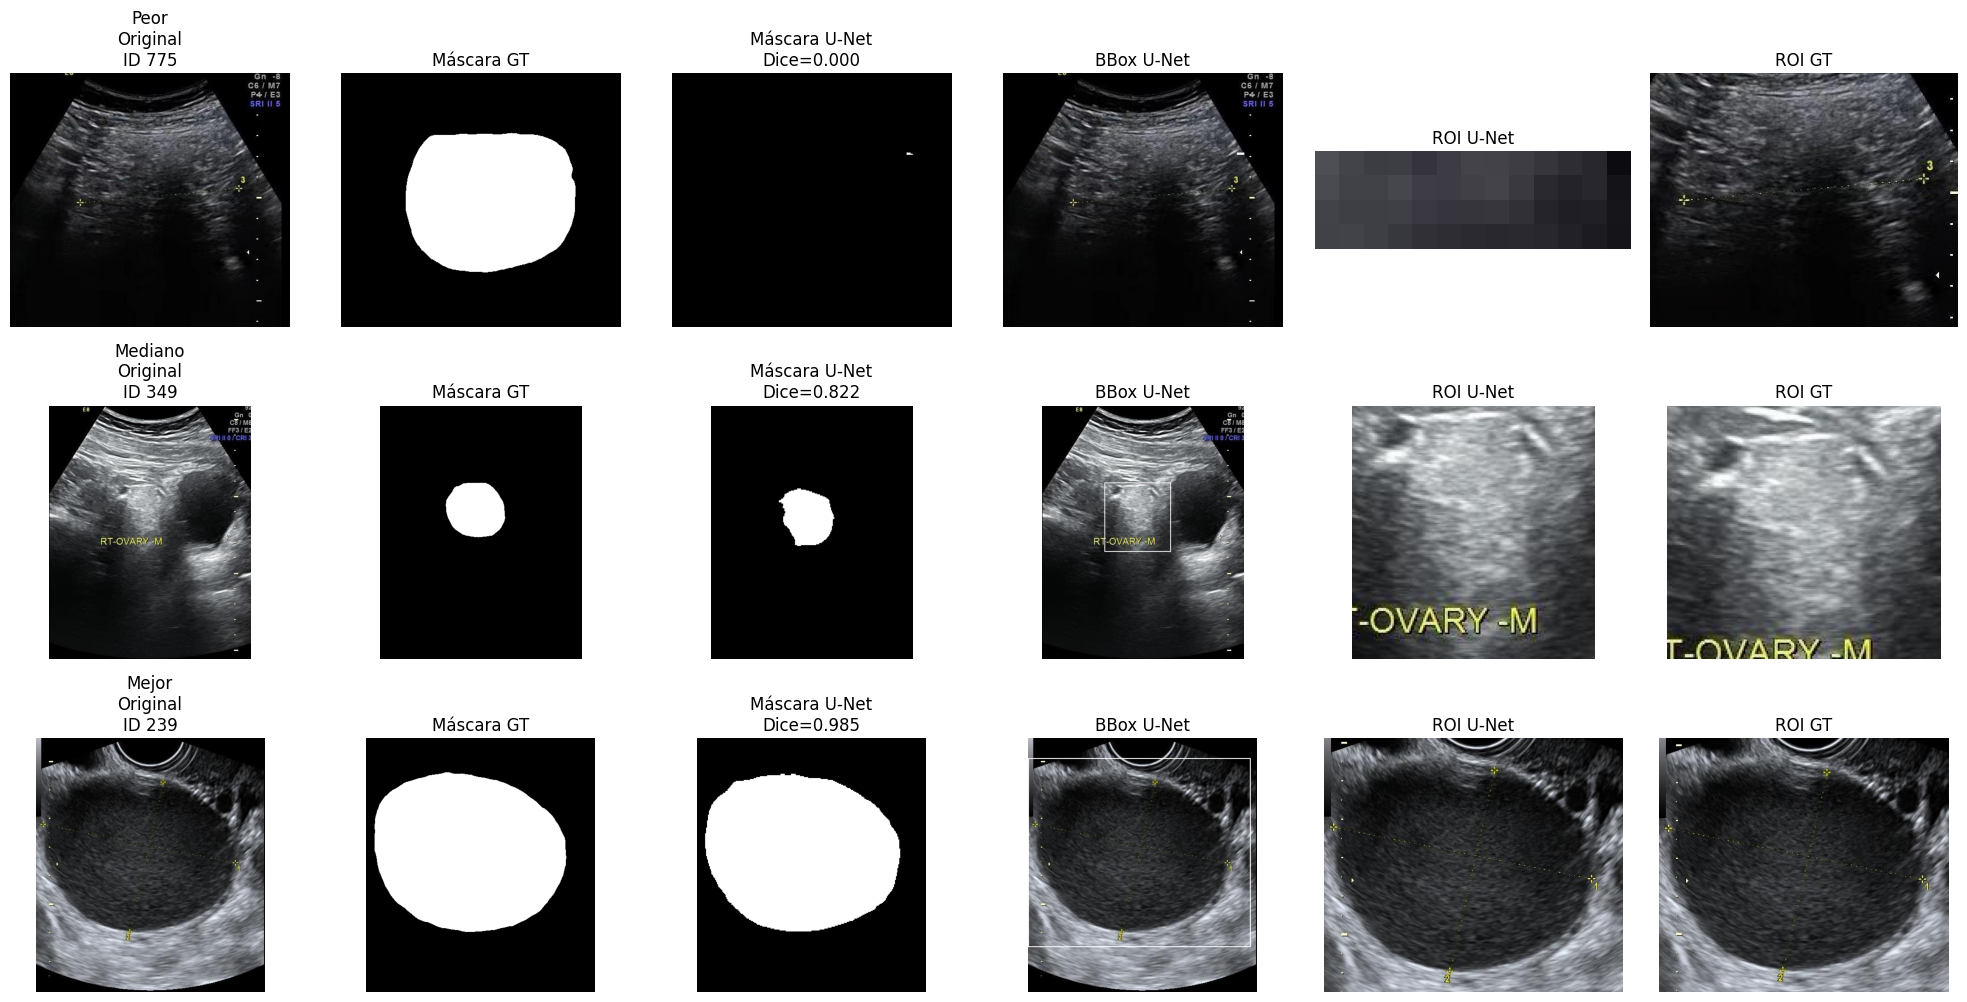

In [7]:
fig, axes = plt.subplots(
    nrows=len(case_results),
    ncols=6,
    figsize=(20, 10),
)

for row, (case_name, result) in enumerate(
    case_results.items()
):
    image = result["image"]

    pred_result = result["predicted_result"]
    gt_result = result["gt_result"]

    image_with_pred_bbox = draw_bbox(
        image,
        pred_result.bbox,
    )

    items = [
        (
            image,
            f"{case_name}\nOriginal\nID {result['image_id']}",
            None,
        ),
        (
            result["gt_mask"],
            "Máscara GT",
            "gray",
        ),
        (
            pred_result.binary_mask,
            (
                "Máscara U-Net\n"
                f"Dice={result['dice']:.3f}"
            ),
            "gray",
        ),
        (
            image_with_pred_bbox,
            "BBox U-Net",
            None,
        ),
        (
            pred_result.roi,
            (
                "ROI U-Net"
                + (
                    "\nFALLBACK"
                    if pred_result.used_fallback
                    else ""
                )
            ),
            None,
        ),
        (
            gt_result.roi,
            "ROI GT",
            None,
        ),
    ]

    for col, (item, title, cmap) in enumerate(items):
        axes[row, col].imshow(
            item,
            cmap=cmap,
        )

        axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 7. Exploración controlada del margen de ROI

Antes de fijar el margen definitivo se recomienda observar únicamente en `validation` cómo cambia el recorte para algunos valores candidatos.

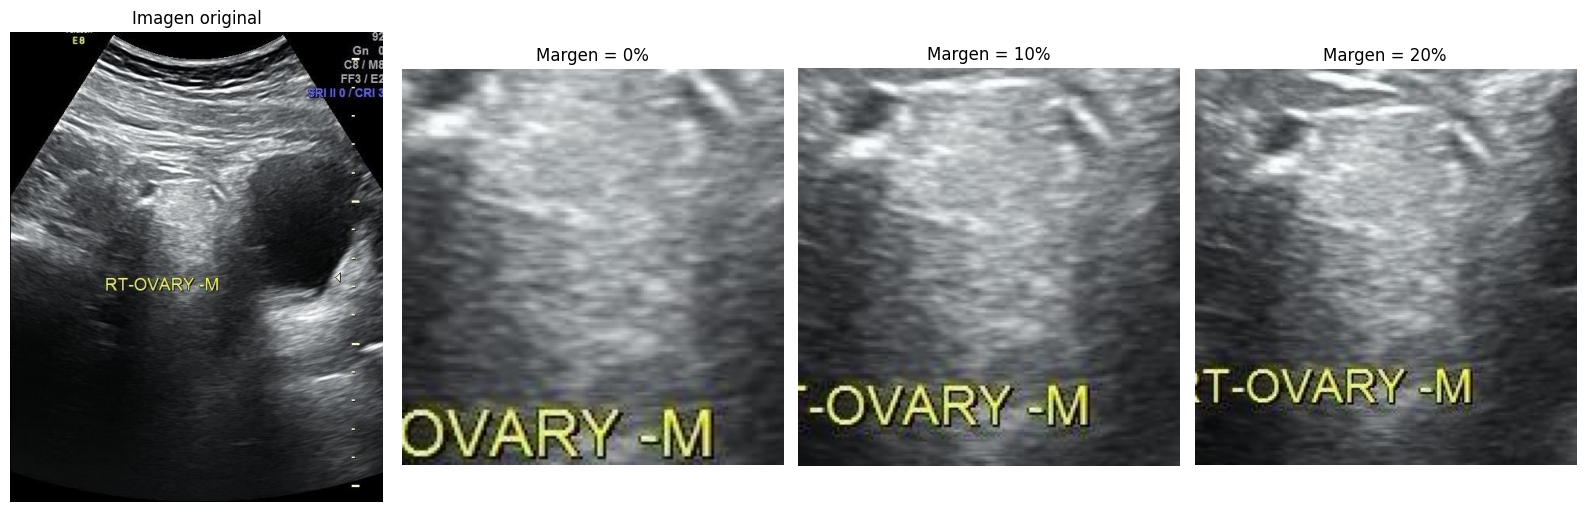

In [8]:
MARGIN_CANDIDATES = [
    0.00,
    0.10,
    0.20,
]


reference_case = case_results["Mediano"]

image = reference_case["image"]

predicted_mask = (
    reference_case["predicted_result"]
    .binary_mask
)


fig, axes = plt.subplots(
    1,
    len(MARGIN_CANDIDATES) + 1,
    figsize=(16, 5),
)

axes[0].imshow(image)
axes[0].set_title("Imagen original")
axes[0].axis("off")


for col, margin in enumerate(
    MARGIN_CANDIDATES,
    start=1,
):
    result = extract_roi_from_mask(
        image=image,
        binary_mask=predicted_mask,
        margin_ratio=margin,
        keep_largest=True,
        fallback_to_full_image=True,
    )

    axes[col].imshow(result.roi)
    axes[col].set_title(
        f"Margen = {margin:.0%}"
    )
    axes[col].axis("off")

plt.tight_layout()
plt.show()

## 8. Criterio de cierre de esta etapa

Una vez validado el procedimiento, el siguiente paso será implementar el experimento controlado:

**A. imagen completa vs. B. ROI U-Net vs. C. ROI GT**

utilizando una misma arquitectura CNN y manteniendo constantes las demás condiciones experimentales.

## 9. Validación visual de las condiciones A/B/C materializadas

Se inspeccionan las ROIs ya generadas y persistidas en disco por `generate_rois.py`.
No se vuelve a ejecutar el U-Net ni a regenerar ROIs.

Casos seleccionados:

| Caso | Split | Motivo |
|------|-------|--------|
| 775 | validation | Fallback B (tiny_component) |
| 869 | validation | Fallback B (tiny_component) |
| 367 | train | Normal (sin fallback) |
| 737 | train | Normal (sin fallback) |
| 360 | validation | Normal (sin fallback) |
| 329 | validation | GT multicomponente (2 componentes) |

In [7]:
# Rutas a los artefactos materializados
DIR_A = PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_experimental"
DIR_B = PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_roi_pred"
DIR_C = PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_roi_gt"
DIR_PRED_MASKS = PROJECT_ROOT / "results" / "segmentation" / "unet_baseline"

CASES = [
    {"image_id": "775", "split": "validation", "label": "Fallback B (tiny_component)"},
    {"image_id": "869", "split": "validation", "label": "Fallback B (tiny_component)"},
    {"image_id": "367", "split": "train",      "label": "Normal"},
    {"image_id": "737", "split": "train",      "label": "Normal"},
    {"image_id": "360", "split": "validation", "label": "Normal"},
    {"image_id": "329", "split": "validation", "label": "GT multicomponente"},
]


def load_materialized_case(case):
    iid = case["image_id"]
    split = case["split"]

    img_a = Image.open(DIR_A / split / "images" / f"{iid}.JPG").convert("RGB")
    pred_mask = Image.open( DIR_PRED_MASKS / split / "predicted_masks" / f"{iid}_pred.png" ).convert("L")
    img_b = Image.open(DIR_B / split / "images" / f"{iid}.png").convert("RGB")
    gt_mask = Image.open(DIR_A / split / "masks" / f"{iid}_binary.PNG").convert("L")
    img_c = Image.open(DIR_C / split / "images" / f"{iid}.png").convert("RGB")

    return img_a, pred_mask, img_b, gt_mask, img_c


print("Rutas configuradas:")
print(f"  A (full image): {DIR_A}")
print(f"  B (ROI pred):   {DIR_B}")
print(f"  C (ROI GT):     {DIR_C}")
print(f"  Pred masks:     {DIR_PRED_MASKS}")
print(f"  Casos: {len(CASES)}")

Rutas configuradas:
  A (full image): /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_experimental
  B (ROI pred):   /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_roi_pred
  C (ROI GT):     /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_roi_gt
  Pred masks:     /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline
  Casos: 6


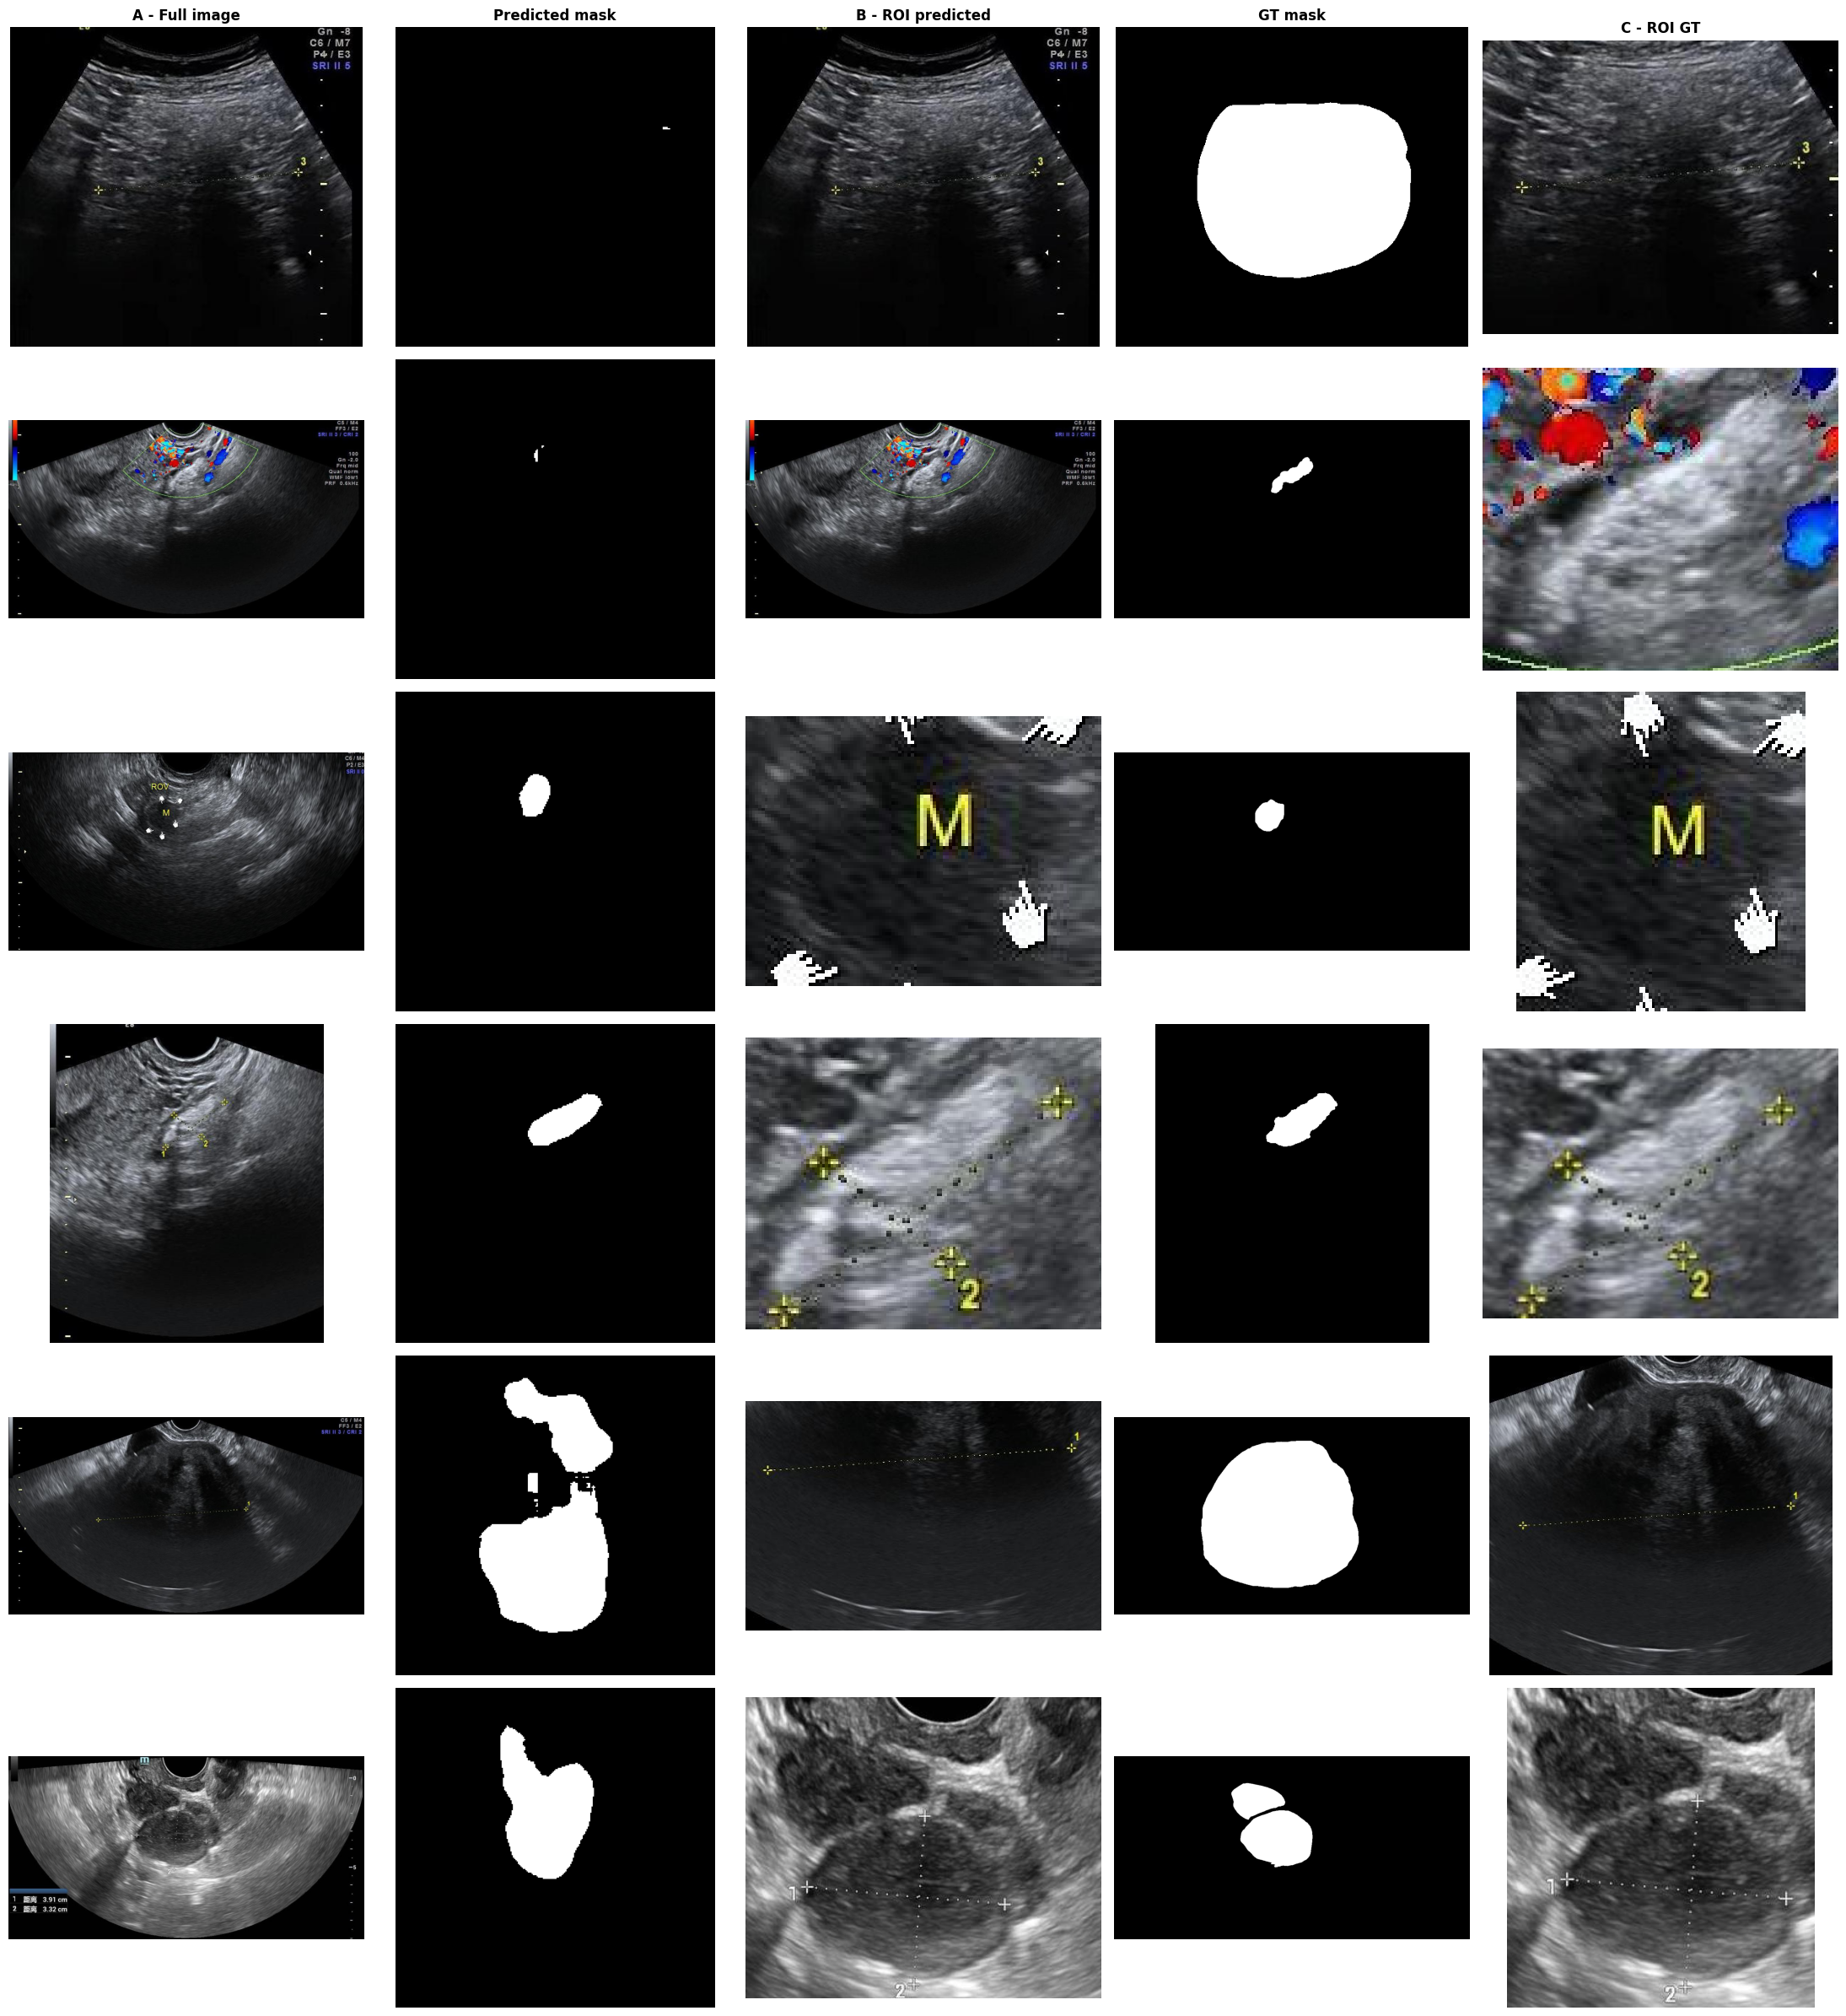

In [8]:
fig, axes = plt.subplots( nrows=len(CASES), ncols=5, figsize=(22, 4 * len(CASES)), )
col_titles = ["A - Full image", "Predicted mask", "B - ROI predicted", "GT mask", "C - ROI GT"]

for row_idx, case in enumerate(CASES):
    img_a, pred_mask, img_b, gt_mask, img_c = load_materialized_case(case)

    items = [
        (img_a, None),
        (pred_mask, "gray"),
        (img_b, None),
        (gt_mask, "gray"),
        (img_c, None),
    ]

    for col_idx, ((item, cmap), col_title) in enumerate(zip(items, col_titles)):
        ax = axes[row_idx, col_idx]
        ax.imshow(item, cmap=cmap)
        if row_idx == 0:
            ax.set_title(col_title, fontsize=12, fontweight="bold")
        ax.axis("off")

    # Etiqueta de fila al margen izquierdo
    axes[row_idx, 0].set_ylabel(
        f"ID {case['image_id']}\n{case['split']}\n{case['label']}",
        fontsize=10, rotation=0, labelpad=80, va="center",
    )

plt.tight_layout()
plt.show()

### 9.1 Verificación de fallback: IDs 775 y 869

Para los dos casos con fallback en condición B, se confirma que la ROI materializada
tiene las mismas dimensiones que la imagen completa (condición A).

In [9]:
fallback_ids = ["775", "869"]

print("Verificación de fallback B:\n")
for iid in fallback_ids:
    img_a = Image.open(DIR_A / "validation" / "images" / f"{iid}.JPG")
    img_b = Image.open(DIR_B / "validation" / "images" / f"{iid}.png")

    size_a = img_a.size  # (width, height)
    size_b = img_b.size
    match = size_a == size_b

    print(f"  ID {iid}:")
    print(f"    A dimensions: {size_a[0]}×{size_a[1]}")
    print(f"    B dimensions: {size_b[0]}×{size_b[1]}")
    print(f"    A.size == B.size: {match}")
    print()

Verificación de fallback B:

  ID 775:
    A dimensions: 493×447
    B dimensions: 493×447
    A.size == B.size: True

  ID 869:
    A dimensions: 972×540
    B dimensions: 972×540
    A.size == B.size: True



### 9.2 Verificación de GT multicomponente: ID 329

La máscara GT del ID 329 tiene 2 componentes conexas separadas.
Se verifica que la condición C (con `keep_largest=False`) preserva ambas
mostrando el conteo de componentes en la GT y que la ROI C cubre un bounding box
mayor que cualquiera de las componentes individuales.

ID 329 - GT multicomponente:
  Componentes conexas en GT: 2
  A dimensions: 1104×569
  C dimensions: 302×314
  C < A (ROI recortó): True


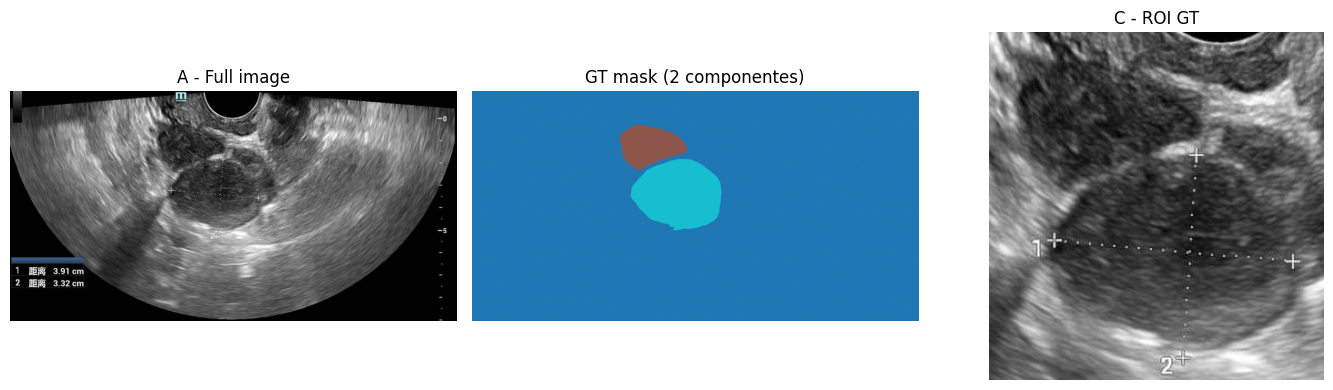

In [10]:
from scipy import ndimage

gt_329 = np.asarray( Image.open(DIR_A / "validation" / "masks" / "329_binary.PNG").convert("L"), dtype=np.uint8, )
gt_bin = (gt_329 > 0).astype(np.uint8)
labeled, n_components = ndimage.label(gt_bin)

roi_c_329 = Image.open(DIR_C / "validation" / "images" / "329.png")
img_a_329 = Image.open(DIR_A / "validation" / "images" / "329.JPG")

print(f"ID 329 - GT multicomponente:")
print(f"  Componentes conexas en GT: {n_components}")
print(f"  A dimensions: {img_a_329.size[0]}×{img_a_329.size[1]}")
print(f"  C dimensions: {roi_c_329.size[0]}×{roi_c_329.size[1]}")
print(f"  C < A (ROI recortó): {roi_c_329.size[0] < img_a_329.size[0] or roi_c_329.size[1] < img_a_329.size[1]}")

# Mostrar componentes etiquetadas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_a_329)
axes[0].set_title("A - Full image")
axes[0].axis("off")
axes[1].imshow(labeled, cmap="tab10")
axes[1].set_title(f"GT mask ({n_components} componentes)")
axes[1].axis("off")
axes[2].imshow(roi_c_329)
axes[2].set_title("C - ROI GT")
axes[2].axis("off")
plt.tight_layout()
plt.show()